# Stage 4: Global Model Comparison

This notebook consolidates the results from all three stages of development:
1. **Manual FIS**: Baseline fuzzy logic system with human-defined parameters.
2. **GA-Tuned FIS**: Fuzzy logic system optimized using Genetic Algorithms.
3. **ANFIS**: Adaptive Neuro-Fuzzy Inference System trained using gradient descent.

**Note**: This notebook loads pre-saved parameters from the `results/` directory. Ensure you have run the export cells in `stage2_ga_fis.ipynb` and `stage3_anfis.ipynb` before running this.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import pickle
import json
import os
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from helper import predict_sugeno, fuzzify, evaluate_rule, sugeno_defuzzification

plt.style.use('ggplot')
print('✅ Imports complete.')

✅ Imports complete.


In [3]:
# 1. Load Data
csv_path = os.path.join('dataset', 'city_day.csv')
raw_df = pd.read_csv(csv_path)
delhi_df = raw_df[raw_df['City'] == 'Delhi'][['Date', 'PM2.5', 'NO2', 'AQI']].dropna().copy()
delhi_df['Date'] = pd.to_datetime(delhi_df['Date'])

X_raw = delhi_df[['PM2.5', 'NO2']].values
y_true = delhi_df['AQI'].values

print(f'📌 Loaded {len(delhi_df)} data points from Delhi.')

📌 Loaded 1998 data points from Delhi.


## 2. Load Model Parameters

In [4]:
# ── Manual FIS Config ──
PM25_MANUAL = {'Low':('left_shoulder',[30,60]), 'Medium':('triangular',[45,90,135]), 'High':('right_shoulder',[110,200])}
NO2_MANUAL  = {'Low':('left_shoulder',[40,80]), 'Medium':('triangular',[60,130,200]), 'High':('right_shoulder',[160,300])}
RULE_BASE   = [
    {'if':[('pm2.5','High'),('no2','High')], 'then':500}, {'if':[('pm2.5','High'),('no2','Medium')], 'then':350},
    {'if':[('pm2.5','High'),('no2','Low')],  'then':250}, {'if':[('pm2.5','Medium'),('no2','High')], 'then':350},
    {'if':[('pm2.5','Medium'),('no2','Medium')], 'then':150}, {'if':[('pm2.5','Medium'),('no2','Low')], 'then':100},
    {'if':[('pm2.5','Low'),('no2','High')],  'then':250}, {'if':[('pm2.5','Low'),('no2','Medium')], 'then':100},
    {'if':[('pm2.5','Low'),('no2','Low')],   'then':50}
]

# ── Load GA Results ──
try:
    with open('results/ga_results.json', 'r') as f:
        ga_data = json.load(f)
    pm25_ga = ga_data['pm25_mf_ga']
    no2_ga  = ga_data['no2_mf_ga']
    rw_ga   = ga_data['rw_ga']
    print('✅ GA Parameters Loaded.')
except Exception as e:
    print(f'❌ Failed to load GA results: {e}')

# ── Load ANFIS Results ──
try:
    with open('results/scalers.pkl', 'rb') as f:
        scalers = pickle.load(f)
    scaler_X = scalers['scaler_X']
    scaler_y = scalers['scaler_y']
    print('✅ ANFIS Scalers Loaded.')
except Exception as e:
    print(f'❌ Failed to load ANFIS scalers: {e}')

✅ GA Parameters Loaded.
✅ ANFIS Scalers Loaded.


In [5]:
class ANFISLayer(nn.Module):
    def __init__(self, n_inputs=2, n_terms=3):
        super(ANFISLayer, self).__init__()
        self.n_inputs = n_inputs
        self.n_terms  = n_terms
        import itertools
        self.rule_idx = list(itertools.product(range(n_terms), repeat=n_inputs))
        self.centers  = nn.Parameter(torch.zeros(n_inputs, n_terms))
        self.sigmas   = nn.Parameter(torch.ones(n_inputs, n_terms))
        self.consequents = nn.Parameter(torch.zeros(n_terms**n_inputs, n_inputs + 1))
    
    def forward(self, x):
        batch = x.size(0)
        x_exp = x.unsqueeze(2)
        c_exp = self.centers.unsqueeze(0)
        s_exp = self.sigmas.unsqueeze(0).abs() + 1e-6
        mu = torch.exp(-((x_exp - c_exp) ** 2) / (2 * s_exp ** 2))
        w_list = []
        for r, idx in enumerate(self.rule_idx):
            w_r = mu[:, 0, idx[0]]
            for i in range(1, len(idx)):
                w_r = w_r * mu[:, i, idx[i]]
            w_list.append(w_r)
        w = torch.stack(w_list, dim=1)
        w_sum = w.sum(dim=1, keepdim=True) + 1e-8
        w_norm = w / w_sum
        x_aug = torch.cat([x, torch.ones(batch, 1, device=x.device)], dim=1)
        f = x_aug @ self.consequents.T
        return (w_norm * f).sum(dim=1, keepdim=True)

anfis_model = ANFISLayer(n_inputs=2, n_terms=3)
try:
    anfis_model.load_state_dict(torch.load('results/anfis_model.pth'))
    anfis_model.eval()
    print('✅ ANFIS Model Weights Loaded.')
except Exception as e:
    print(f'❌ Failed to load ANFIS weights: {e}')

✅ ANFIS Model Weights Loaded.


## 3. Run Inference

In [6]:
# ── Manual Inference ──
preds_manual = np.array([
    predict_sugeno({'pm2.5': p, 'no2': n}, {'pm2.5': PM25_MANUAL, 'no2': NO2_MANUAL}, RULE_BASE)
    for p, n in X_raw
])

# ── GA Inference ──
preds_ga = np.array([
    predict_sugeno({'pm2.5': p, 'no2': n}, {'pm2.5': pm25_ga, 'no2': no2_ga}, RULE_BASE, rw_ga)
    for p, n in X_raw
])

# ── ANFIS Inference ──
X_norm = scaler_X.transform(X_raw)
X_tensor = torch.tensor(X_norm, dtype=torch.float32)
with torch.no_grad():
    y_norm_pred = anfis_model(X_tensor).numpy()
preds_anfis = scaler_y.inverse_transform(y_norm_pred).flatten()

print('✅ All predictions generated.')

✅ All predictions generated.


## 4. Performance Metrics

In [9]:
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

m_mae, m_rmse, m_r2 = calculate_metrics(y_true, preds_manual)
g_mae, g_rmse, g_r2 = calculate_metrics(y_true, preds_ga)
a_mae, a_rmse, a_r2 = calculate_metrics(y_true, preds_anfis)

summary = pd.DataFrame({
    'Model': ['Manual FIS', 'GA-Tuned FIS', 'ANFIS'],
    'MAE': [m_mae, g_mae, a_mae],
    'RMSE': [m_rmse, g_rmse, a_rmse],
    'R2 Score': [m_r2, g_r2, a_r2]
})
display(summary.style.highlight_min(subset=['MAE', 'RMSE'], color='green').highlight_max(subset=['R2 Score'], color='green'))

,Model,MAE,RMSE,R2 Score
0,Manual FIS,103.334670,120.607796,-0.019634
1,GA-Tuned FIS,44.937296,63.050744,0.721340
2,ANFIS,36.765569,50.216369,0.823240


## 5. Visual Comparison

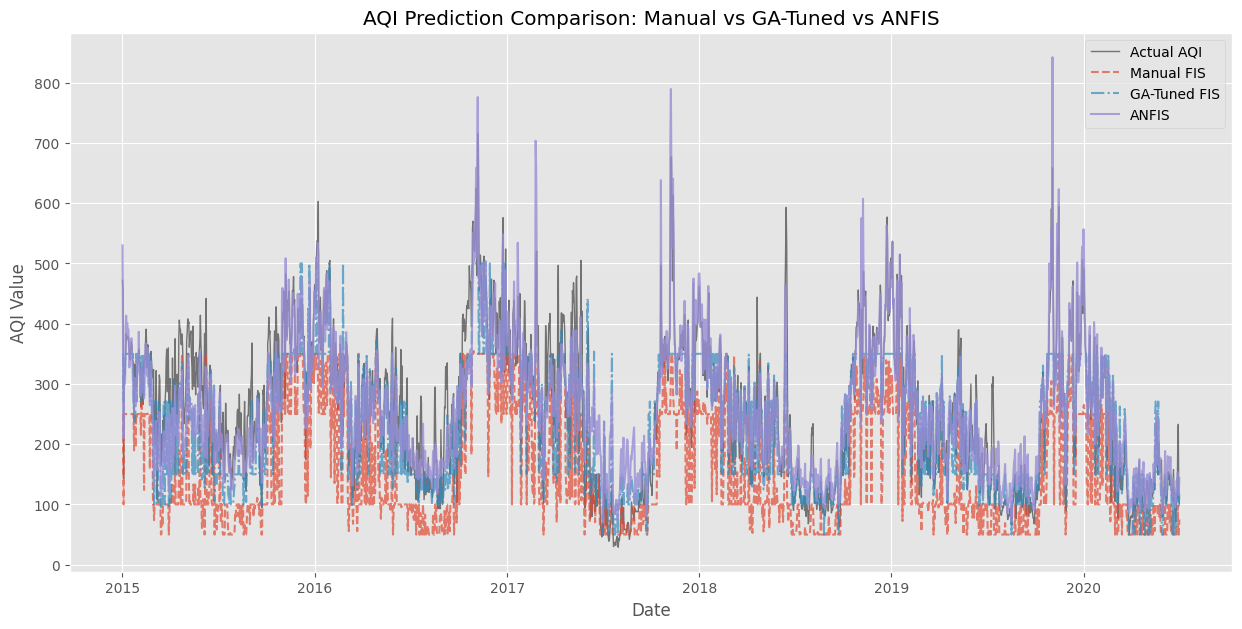

In [10]:
plt.figure(figsize=(15, 7))
plt.plot(delhi_df['Date'], y_true, label='Actual AQI', color='black', alpha=0.5, linewidth=1)
plt.plot(delhi_df['Date'], preds_manual, label='Manual FIS', linestyle='--', alpha=0.7)
plt.plot(delhi_df['Date'], preds_ga, label='GA-Tuned FIS', linestyle='-.', alpha=0.7)
plt.plot(delhi_df['Date'], preds_anfis, label='ANFIS', alpha=0.8)
plt.title('AQI Prediction Comparison: Manual vs GA-Tuned vs ANFIS')
plt.xlabel('Date')
plt.ylabel('AQI Value')
plt.legend()
plt.show()

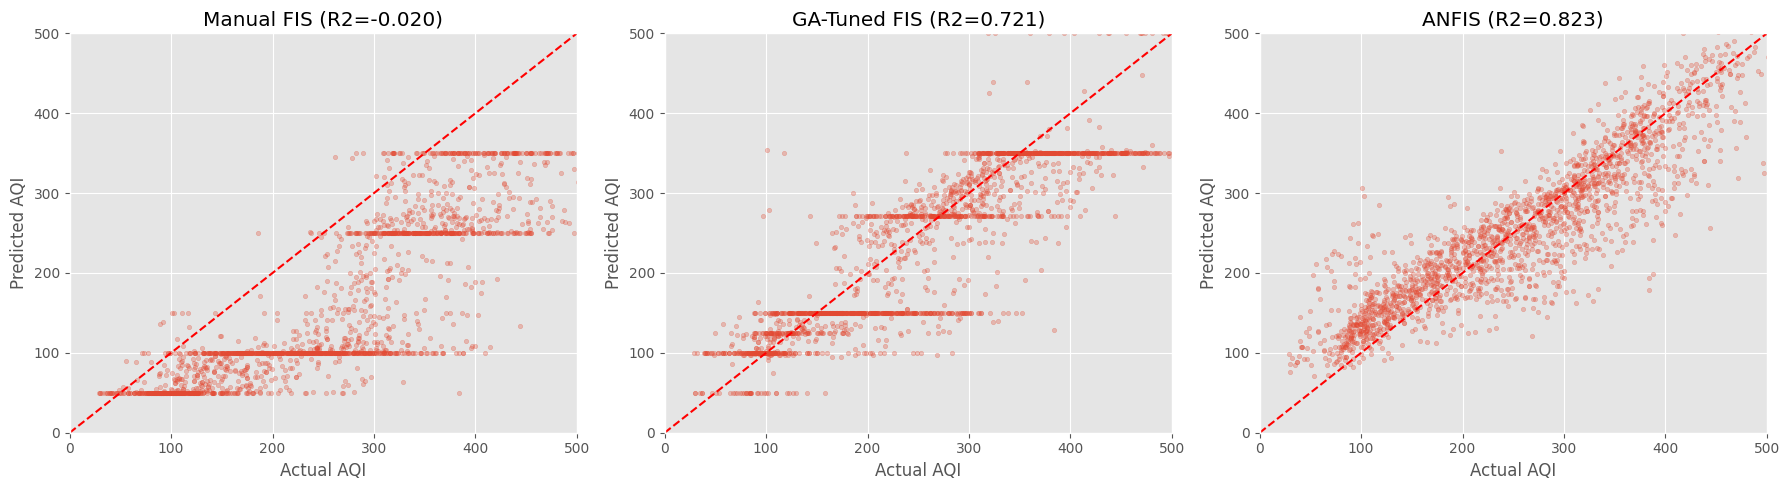

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [('Manual FIS', preds_manual), ('GA-Tuned FIS', preds_ga), ('ANFIS', preds_anfis)]

for i, (name, pred) in enumerate(models):
    axes[i].scatter(y_true, pred, alpha=0.3, s=10)
    axes[i].plot([0, 500], [0, 500], '--', color='red')
    axes[i].set_title(f'{name} (R2={r2_score(y_true, pred):.3f})')
    axes[i].set_xlabel('Actual AQI')
    axes[i].set_ylabel('Predicted AQI')
    axes[i].set_xlim(0, 500)
    axes[i].set_ylim(0, 500)

plt.tight_layout()
plt.show()